#### Analysis Goal
Generating reliable production expectations and risk bands for investment planning by removing the 2015–2023 monthly and annual solar irradiance patterns from PVGIS data for Istanbul.

### Success Criteria

This notebook is considered successful if all of the following conditions are met:

1. **Reproducible environment is confirmed**  
   Python executable, package versions, and random seed are explicitly set and printed.

2. **Data quality and schema checks pass with zero critical errors**  
   - Required columns exist (`year`, `month`, `avg_ghi_w_m2`, `hour_count`)  
   - No nulls in critical fields  
   - No duplicate `year-month` records  
   - Valid value ranges (`month` in 1–12, `avg_ghi_w_m2 >= 0`, `hour_count` in expected range)

3. **Time coverage is complete and consistent**  
   The dataset contains full monthly coverage for 2015–2023 (12 months per year, 108 rows total).

4. **Core analytical outputs are produced and interpretable**  
   - Seasonality profile by month  
   - Annual trend with slope estimate  
   - Monthly uncertainty/risk view using P10–P50–P90 band

5. **Decision-ready insight is generated for planning**  
   The notebook translates results into actionable investment guidance using base-case (`P50`) and downside (`P10`) perspectives.

6. **Outputs are exportable for downstream use**  
   Key summary artifacts (e.g., monthly statistics) are written to the output directory without errors.

In [3]:
import sys, platform, pandas as pd, numpy as np
print("Python:", sys.version)
print("Executable:", sys.executable)
print("Platform:", platform.platform())
print("pandas:", pd.__version__, "| numpy:", np.__version__)

Python: 3.11.9 (main, Apr 13 2026, 17:55:17) [Clang 21.0.0 (clang-2100.0.123.102)]
Executable: /Users/huseyinkucukogul/enerlytics-ai/.venv/bin/python
Platform: macOS-26.4.1-arm64-arm-64bit
pandas: 3.0.2 | numpy: 2.4.4


In [4]:
import os, random, numpy as np
random.seed(42)
np.random.seed(42)
os.environ["TZ"] = "Europe/Istanbul"

In [5]:
from pathlib import Path

In [6]:
monthly_path = "/Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/data/processed/pvgis_monthly_41.0082_28.9784_2015_2026.csv"
annual_path = "/Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/data/processed/pvgis_annual_summary_41.0082_28.9784_2015_2026.csv"
m = pd.read_csv(monthly_path)
a = pd.read_csv(annual_path)

required_m = {"year", "month", "avg_ghi_w_m2", "hour_count"}
missing_m = required_m - set(m.columns)
assert not missing_m, f"Monthly missing columns: {missing_m}"

m["year"] = pd.to_numeric(m["year"], errors="raise").astype(int)
m["month"] = pd.to_numeric(m["month"], errors="raise").astype(int)
m["hour_count"] = pd.to_numeric(m["hour_count"], errors="raise").astype(int)
m["avg_ghi_w_m2"] = pd.to_numeric(m["avg_ghi_w_m2"], errors="raise")

assert m[["year", "month", "avg_ghi_w_m2", "hour_count"]].isna().sum().sum() == 0, "Monthly has nulls"

assert m["month"].between(1, 12).all(), "month out of range"
assert (m["avg_ghi_w_m2"] >= 0).all(), "negative GHI found"
assert m["hour_count"].between(672, 744).all(), "hour_count out of expected range"

assert not m.duplicated(subset=["year", "month"]).any(), "duplicate year-month rows"

assert m["year"].min() >= 2015 and m["year"].max() <= 2023, "year range unexpected"

assert "year" in a.columns, "Annual missing year"
assert not a["year"].duplicated().any(), "Annual has duplicate years"
print("Data transformation checks were passed.")

Data transformation checks were passed.


In [7]:
path = "/Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/data/processed/pvgis_monthly_41.0082_28.9784_2015_2026.csv"
df = pd.read_csv(path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

null_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("\nNull %:\n", null_pct)

dup_count = df.duplicated(subset=["year", "month"]).sum()
print("\nDuplicate year-month:", dup_count)

print("\nMonth out of range:", (~df["month"].between(1, 12)).sum())
print("Negative GHI:", (df["avg_ghi_w_m2"] < 0).sum())
print("Hour_count out of [672,744]:", (~df["hour_count"].between(672, 744)).sum())

months_per_year = df.groupby("year")["month"].nunique()
print("\nMonths per year:\n", months_per_year)

q1, q3 = df["avg_ghi_w_m2"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df["avg_ghi_w_m2"] < low) | (df["avg_ghi_w_m2"] > high)]
print(f"\nOutlier count (IQR): {len(outliers)}")
display(outliers.head())

Shape: (108, 8)

Columns: ['year', 'month', 'year_month', 'avg_ghi_w_m2', 'hour_count', 'source', 'latitude', 'longitude']

Null %:
 year            0.0
month           0.0
year_month      0.0
avg_ghi_w_m2    0.0
hour_count      0.0
source          0.0
latitude        0.0
longitude       0.0
dtype: float64

Duplicate year-month: 0

Month out of range: 0
Negative GHI: 0
Hour_count out of [672,744]: 0

Months per year:
 year
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
Name: month, dtype: int64

Outlier count (IQR): 0


,year,month,year_month,avg_ghi_w_m2,hour_count,source,latitude,longitude


In [8]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
PROJECT_ROOT = Path("/Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai")
DATA_MONTHLY = PROJECT_ROOT / "data/processed/pvgis_monthly_41.0082_28.9784_2015_2026.csv"
OUT_DIR = PROJECT_ROOT / "analysis/outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
def load_monthly(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)

def validate_monthly(df: pd.DataFrame) -> None:
    required = {"year","month","avg_ghi_w_m2","hour_count"}
    assert required.issubset(df.columns), "Missing required columns"
    assert not df.duplicated(["year","month"]).any(), "Duplicate year-month"
    assert df["month"].between(1,12).all(), "Invalid month"
    assert (df["avg_ghi_w_m2"] >= 0).all(), "Negative GHI"

def add_time_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["date"] = pd.to_datetime(dict(year=out["year"], month=out["month"], day=1))
    return out.sort_values("date")

In [10]:
df = load_monthly(DATA_MONTHLY)
validate_monthly(df)
df = add_time_cols(df)
print(df.shape)
df.head()

(108, 9)


,year,month,year_month,avg_ghi_w_m2,hour_count,source,latitude,longitude,date
0,2015,1,2015-01,74.6360,744,PVGIS,41.0082,28.9784,2015-01-01
1,2015,2,2015-02,88.1236,672,PVGIS,41.0082,28.9784,2015-02-01
2,2015,3,2015-03,130.0413,744,PVGIS,41.0082,28.9784,2015-03-01
3,2015,4,2015-04,215.6388,720,PVGIS,41.0082,28.9784,2015-04-01
4,2015,5,2015-05,269.4139,744,PVGIS,41.0082,28.9784,2015-05-01


In [11]:
monthly_stats = df.groupby("month")["avg_ghi_w_m2"].agg(["mean","median","std"])
monthly_stats.to_csv(OUT_DIR / "monthly_stats.csv", index=True)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
data_path = Path("/Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/data/processed/pvgis_monthly_41.0082_28.9784_2015_2026.csv")
df = pd.read_csv(data_path)

df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df = df.sort_values("date").reset_index(drop=True)
print(df.shape)
df.head()

(108, 9)


,year,month,year_month,avg_ghi_w_m2,hour_count,source,latitude,longitude,date
0,2015,1,2015-01,74.6360,744,PVGIS,41.0082,28.9784,2015-01-01
1,2015,2,2015-02,88.1236,672,PVGIS,41.0082,28.9784,2015-02-01
2,2015,3,2015-03,130.0413,744,PVGIS,41.0082,28.9784,2015-03-01
3,2015,4,2015-04,215.6388,720,PVGIS,41.0082,28.9784,2015-04-01
4,2015,5,2015-05,269.4139,744,PVGIS,41.0082,28.9784,2015-05-01


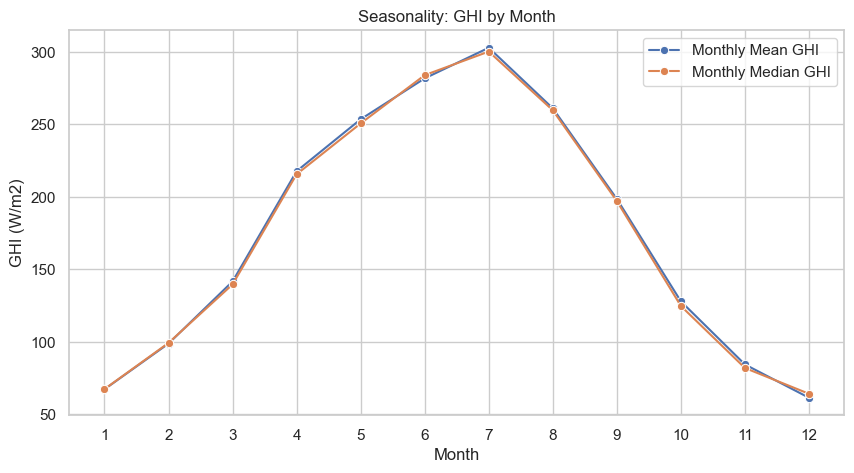

,month,mean_ghi,median_ghi,std_ghi
0,1,67.315856,67.4302,5.763463
1,2,98.853111,99.3051,11.128212
2,3,141.718456,139.6571,13.436885
3,4,217.763778,215.6388,19.079229
4,5,253.569400,250.7047,24.726338
5,6,281.785356,284.0072,11.822341
6,7,302.891911,300.2729,13.949397
7,8,261.111300,259.7422,13.192318
8,9,198.581756,197.1141,8.882690
9,10,127.930800,124.7360,12.485464


In [13]:
month_stats = (
    df.groupby("month", as_index=False)["avg_ghi_w_m2"]
      .agg(mean_ghi="mean", median_ghi="median", std_ghi="std")
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=month_stats, x="month", y="mean_ghi", marker="o", label="Monthly Mean GHI")
sns.lineplot(data=month_stats, x="month", y="median_ghi", marker="o", label="Monthly Median GHI")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("GHI (W/m2)")
plt.title("Seasonality: GHI by Month")
plt.legend()
plt.show()

month_stats

**Production seasonality is highly pronounced:** Production potential in the Istanbul location peaks during the summer months and reaches its lowest levels during the winter months; Therefore, seasonal-based revenue and production planning should be preferred over relying on a single annual average.

**Revenue and cash flow should be managed periodically:** The high-production period (late spring and summer) acts as the primary driver of revenue generation, while during the low-production period (late autumn and winter), budgeting, grid/storage strategy, and O&M planning should be structured more conservatively.

**The risk profile is manageable and predictable:** Since the production curve is regular and consistent, optimizing capacity planning, maintenance schedules, and performance targets according to seasonal cycles increases the predictability of the investment.

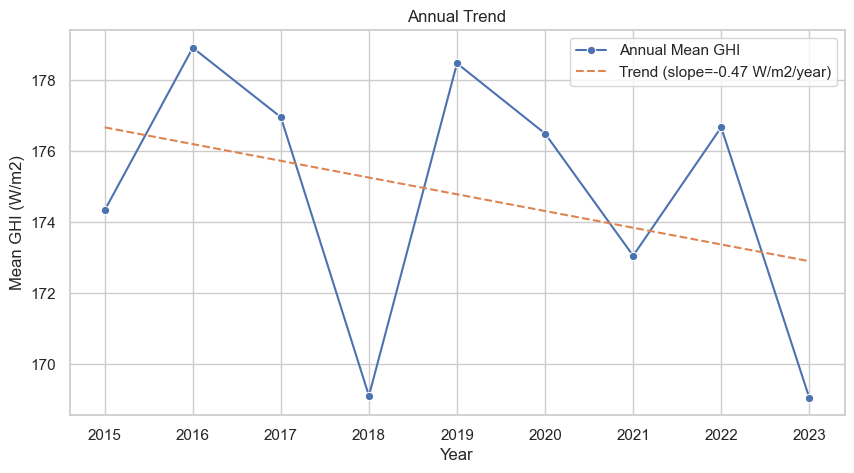

,year,annual_avg_ghi_w_m2,trend_line
0,2015,174.336317,176.672567
1,2016,178.918567,176.200767
2,2017,176.960517,175.728967
3,2018,169.101008,175.257166
4,2019,178.478883,174.785366
5,2020,176.498717,174.313565
6,2021,173.052950,173.841765
7,2022,176.674967,173.369964
8,2023,169.046367,172.898164


In [14]:
annual = (
    df.groupby("year", as_index=False)["avg_ghi_w_m2"]
      .mean()
      .rename(columns={"avg_ghi_w_m2": "annual_avg_ghi_w_m2"})
)

x = annual["year"].values
y = annual["annual_avg_ghi_w_m2"].values
slope, intercept = np.polyfit(x, y, 1)
annual["trend_line"] = slope * annual["year"] + intercept

plt.figure(figsize=(10, 5))
sns.lineplot(data=annual, x="year", y="annual_avg_ghi_w_m2", marker="o", label="Annual Mean GHI")
sns.lineplot(data=annual, x="year", y="trend_line", linestyle="--", label=f"Trend (slope={slope:.2f} W/m2/year)")
plt.xlabel("Year")
plt.ylabel("Mean GHI (W/m2)")
plt.title("Annual Trend")
plt.legend()
plt.show()

annual

### Executive Insight

The annual GHI trend for Istanbul (2015-2023) indicates a **slight long-term decline** (`-0.47 W/m2/year`), but year-to-year variability is more pronounced than the trend itself.

While the structural seasonality remains stable, interannual fluctuations are material: **2016 and 2019** stand out as relatively strong years, whereas **2018 and 2023** are notably weak. This suggests that planning based only on a single long-term average may understate downside risk.

From an investment perspective, decision-making should be based on **scenario bands (P10-P50-P90)** rather than a point estimate.  
- **P50** should be used as the base case for expected production.  
- **P10** should anchor downside resilience (debt sizing, cash-flow stress).  
- **P90** should be treated as upside potential, not baseline expectation.

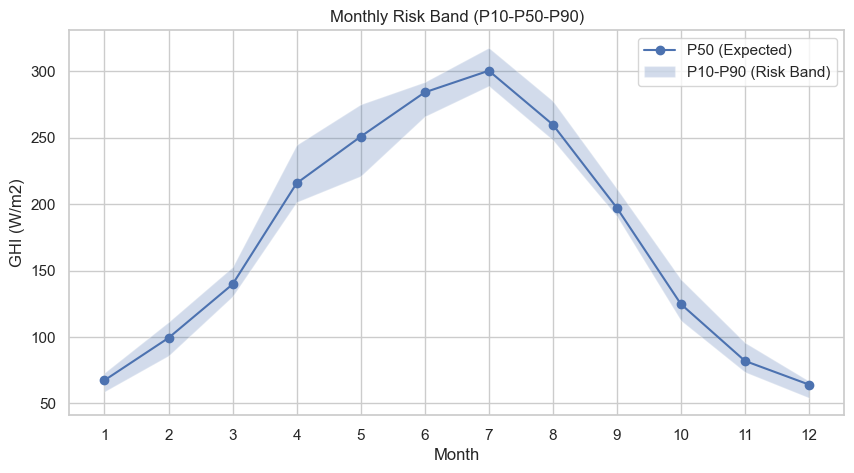

level_1,month,p10,p50,p90
0,1,58.95726,67.4302,73.12744
1,2,85.95084,99.3051,111.25834
2,3,130.61098,139.6571,152.65756
3,4,201.49228,215.6388,244.48736
4,5,221.03710,250.7047,274.98748
5,6,265.88534,284.0072,291.78606
6,7,288.84116,300.2729,317.54994
7,8,248.17100,259.7422,277.53596
8,9,190.79066,197.1141,211.53612
9,10,112.35636,124.7360,143.34790


In [15]:
risk_band = (
    df.groupby("month", as_index=False)["avg_ghi_w_m2"]
      .quantile([0.10, 0.50, 0.90])
      .pivot(index="month", columns="level_1", values="avg_ghi_w_m2")
      .reset_index()
      .rename(columns={0.1: "p10", 0.5: "p50", 0.9: "p90"})
)

plt.figure(figsize=(10, 5))
plt.plot(risk_band["month"], risk_band["p50"], marker="o", label="P50 (Expected)")
plt.fill_between(risk_band["month"], risk_band["p10"], risk_band["p90"], alpha=0.25, label="P10-P90 (Risk Band)")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("GHI (W/m2)")
plt.title("Monthly Risk Band (P10-P50-P90)")
plt.legend()
plt.show()

risk_band

Top 3 highest-risk months:


level_1,month,p10,p50,p90,band_width,risk_score
10,11,73.62984,81.9959,95.76928,22.13944,0.270007
1,2,85.95084,99.3051,111.25834,25.30750,0.254846
9,10,112.35636,124.7360,143.34790,30.99154,0.248457


Top 3 lowest-risk months:


level_1,month,p10,p50,p90,band_width,risk_score
8,9,190.79066,197.1141,211.53612,20.74546,0.105246
6,7,288.84116,300.2729,317.54994,28.70878,0.095609
5,6,265.88534,284.0072,291.78606,25.90072,0.091197


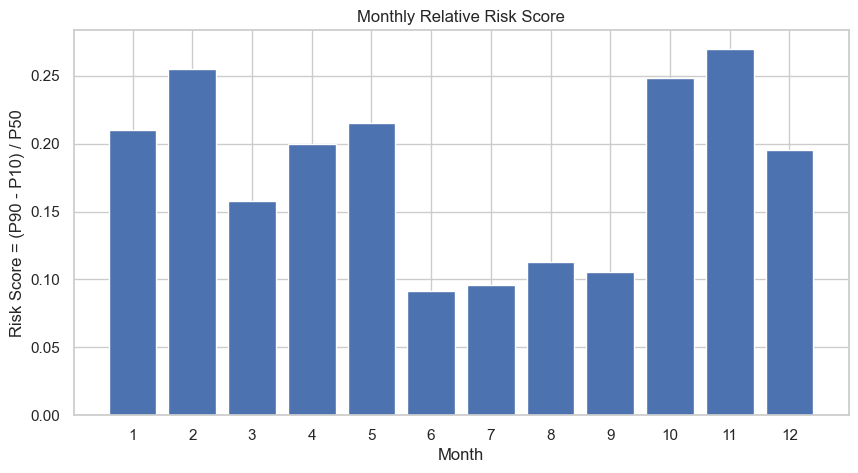

In [16]:
risk_score = risk_band.copy()
risk_score["band_width"] = risk_score["p90"] - risk_score["p10"]
risk_score["risk_score"] = risk_score["band_width"] / risk_score["p50"]

risk_score_sorted = risk_score.sort_values("risk_score", ascending=False)

print("Top 3 highest-risk months:")
display(risk_score_sorted[["month", "p10", "p50", "p90", "band_width", "risk_score"]].head(3))

print("Top 3 lowest-risk months:")
display(risk_score_sorted[["month", "p10", "p50", "p90", "band_width", "risk_score"]].tail(3))

plt.figure(figsize=(10, 5))
plt.bar(risk_score["month"], risk_score["risk_score"])
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Risk Score = (P90 - P10) / P50")
plt.title("Monthly Relative Risk Score")
plt.show()

In [17]:
risk_labeled = risk_score[["month", "risk_score"]].copy()

q_low = risk_labeled["risk_score"].quantile(1/3)
q_high = risk_labeled["risk_score"].quantile(2/3)

def label_risk(x):
    if x <= q_low:
        return "Low"
    elif x <= q_high:
        return "Medium"
    return "High"

risk_labeled["risk_level"] = risk_labeled["risk_score"].apply(label_risk)

risk_labeled = risk_labeled.sort_values("month").reset_index(drop=True)
display(risk_labeled)

print("Low-risk months:", risk_labeled.loc[risk_labeled["risk_level"] == "Low", "month"].tolist())
print("Medium-risk months:", risk_labeled.loc[risk_labeled["risk_level"] == "Medium", "month"].tolist())
print("High-risk months:", risk_labeled.loc[risk_labeled["risk_level"] == "High", "month"].tolist())

level_1,month,risk_score,risk_level
0,1,0.210146,Medium
1,2,0.254846,High
2,3,0.157862,Medium
3,4,0.199385,Medium
4,5,0.215195,High
5,6,0.091197,Low
6,7,0.095609,Low
7,8,0.113054,Low
8,9,0.105246,Low
9,10,0.248457,High


Low-risk months: [6, 7, 8, 9]
Medium-risk months: [1, 3, 4, 12]
High-risk months: [2, 5, 10, 11]


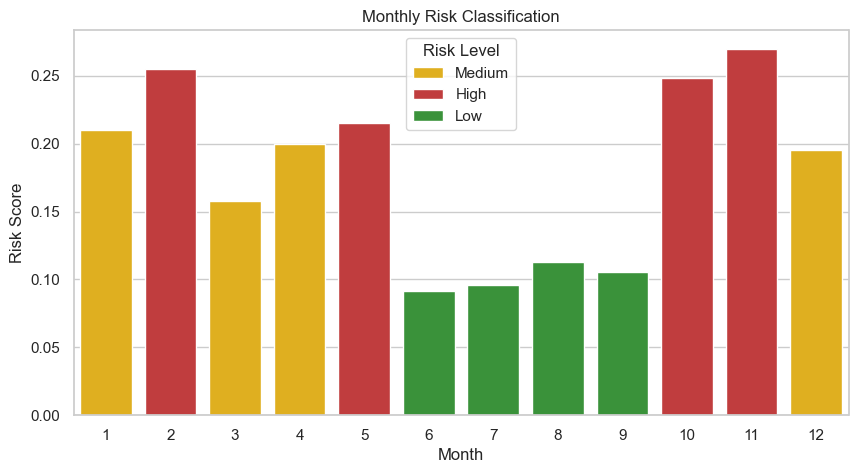

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(data=risk_labeled, x="month", y="risk_score", hue="risk_level", dodge=False,
            palette={"Low": "#2ca02c", "Medium": "#ffbf00", "High": "#d62728"})
plt.xlabel("Month")
plt.ylabel("Risk Score")
plt.title("Monthly Risk Classification")
plt.legend(title="Risk Level")
plt.show()

In [19]:
best_month = month_stats.loc[month_stats["mean_ghi"].idxmax(), "month"]
worst_month = month_stats.loc[month_stats["mean_ghi"].idxmin(), "month"]

print(f"Strongest month: {int(best_month)} | Weakest month: {int(worst_month)}")
print(f"Annual trend slope: {slope:.2f} W/m2/year")
print("Comment: Months with a wider P10-P90 band carry higher uncertainty/risk.")

Strongest month: 7 | Weakest month: 12
Annual trend slope: -0.47 W/m2/year
Comment: Months with a wider P10-P90 band carry higher uncertainty/risk.
